In [1]:
import numpy as np
np.random.seed(42)  # 乱数シードを固定

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


class LinearInParameterLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.5, max_iter=10000, l2_lambda=0.0, 
                 early_stopping_rounds=5, early_stopping_tolerance=1e-3, early_stopping_metric=['loss', 'misclassification_rate'][0],
                 verbose=False):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.l2_lambda = l2_lambda
        self.early_stopping_rounds = early_stopping_rounds
        self.early_stopping_tolerance = early_stopping_tolerance
        self.early_stopping_metric = early_stopping_metric
        self.verbose = verbose

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _objective(self, theta, X, y):
        """Compute training loss (cross-entropy + L2 regularization)."""
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        ce = -np.mean(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10))
        reg = self.l2_lambda * np.sum(theta[1:] ** 2)
        return ce + reg

    def _loss_no_reg(self, theta, X, y):
        """Compute loss without L2 regularization."""
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        return -np.mean(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10))

    def _gradient(self, theta, X, y):
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        grad = (1 / m) * X.T.dot(h - y)
        grad[1:] += 2 * self.l2_lambda * theta[1:]
        return grad

    def fit(self, X, y, X_val=None, y_val=None, X_test=None, y_test=None):
        """Train the model with gradient descent and early stopping."""
        self.theta_ = np.random.randn(X.shape[1]) * 0.01
        self.theta_init_ = self.theta_.copy()
        self.train_loss_, self.val_loss_, self.test_loss_ = [], [], []
        self.val_misclass_, self.test_misclass_ = [], []

        best_val_metric = np.inf
        no_improve = 0
        for i in range(self.max_iter):
            self.theta_ -= self.learning_rate * self._gradient(self.theta_, X, y)
            self.train_loss_.append(self._objective(self.theta_, X, y))

            if X_val is not None and y_val is not None:
                val_loss = self._loss_no_reg(self.theta_, X_val, y_val)
                self.val_loss_.append(val_loss)
                val_misclass = np.mean(self.predict(X_val) != y_val)
                self.val_misclass_.append(val_misclass)

                if self.early_stopping_metric == 'loss':
                    val_metric = val_loss
                elif self.early_stopping_metric == 'misclassification_rate':
                    val_metric = val_misclass

                if val_metric < best_val_metric - self.early_stopping_tolerance:
                    best_val_metric = val_metric
                    no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping at iter {i}")
                    break

            if X_test is not None and y_test is not None:
                self.test_loss_.append(self._loss_no_reg(self.theta_, X_test, y_test))
                self.test_misclass_.append(np.mean(self.predict(X_test) != y_test))

        return self

    def predict(self, X):
        return (self._sigmoid(X.dot(self.theta_)) >= 0.5).astype(int)
    
    def predict_proba(self, X):
        """Return probability estimates for the input samples.
           Output shape: (n_samples, 2) where column 0 is P(class=0) and column 1 is P(class=1)."""
        probs = self._sigmoid(X.dot(self.theta_))
        return np.column_stack((1 - probs, probs))


# --- Define the palette ---
palette = {
    "Orange": "#FFA500",
    "Dark Orange": "#FF8C00",
    "Gray": "#808080",
    "Blue": "#0000FF",
    "Light Blue": "#ADD8E6",
    "Light Light Blue": "#E0FFFF",
    "Purple": "#800080"
}
region_cmap = ListedColormap(["#E0FFFF", "#FFF5E6"])

# --- Generate and preprocess data ---
X, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# --- Hyperparameter Selection ---
polynomial_degree = 30
best_l2_lambda = min([0.001, 0.01, 0.1, 1.0], key=lambda reg: 
    LinearInParameterLogisticRegression(l2_lambda=reg).fit(
        PolynomialFeatures(polynomial_degree).fit_transform(X_train), y_train,
        X_val=PolynomialFeatures(polynomial_degree).fit_transform(X_val), y_val=y_val
    ).val_loss_[-1]
)

# --- Feature Transformation ---
poly = PolynomialFeatures(degree=polynomial_degree, include_bias=False)
X_train_poly, X_val_poly, X_test_poly = [np.c_[np.ones(X_.shape[0]), poly.fit_transform(X_)] 
                                         for X_ in [X_train, X_val, X_test]]

# --- Instantiate and train the model ---
model = LinearInParameterLogisticRegression(l2_lambda=best_l2_lambda, verbose=True)
model.fit(X_train_poly, y_train, X_val=X_val_poly, y_val=y_val, X_test=X_test_poly, y_test=y_test)


Early stopping at iter 289


LinearInParameterLogisticRegression(l2_lambda=0.001, verbose=True)

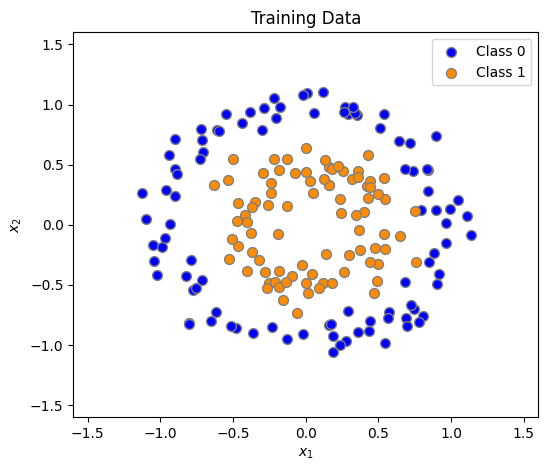

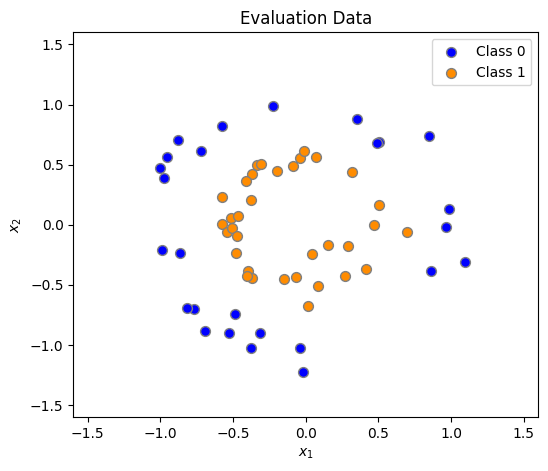

/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_2127/1512721422.py:25: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


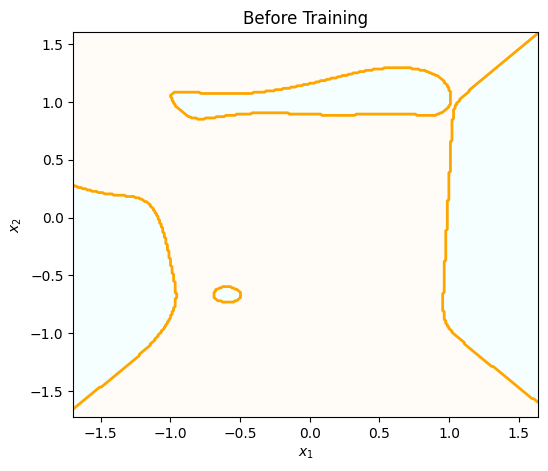

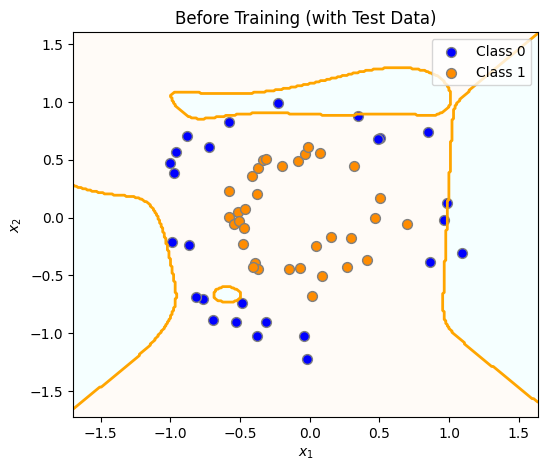

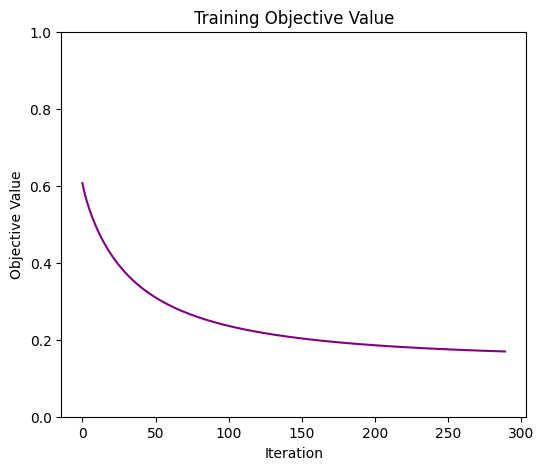

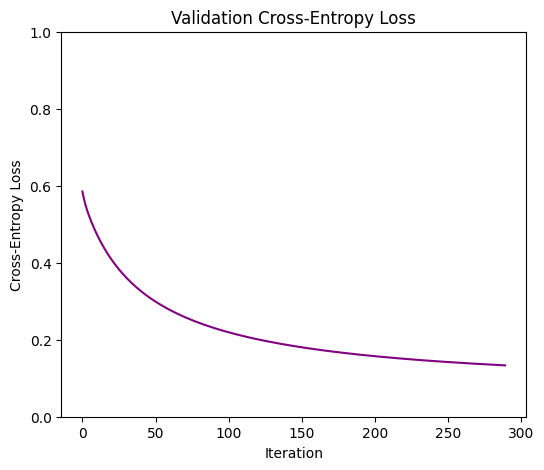

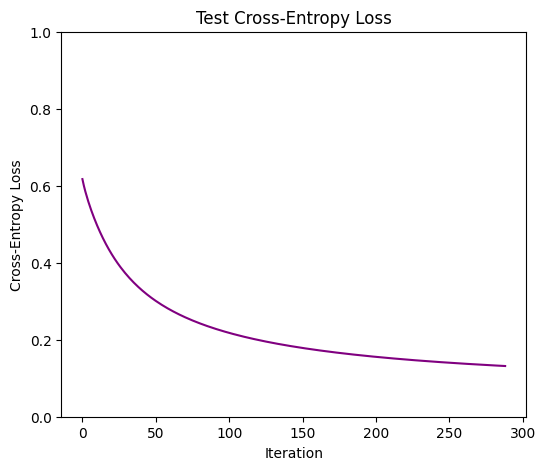

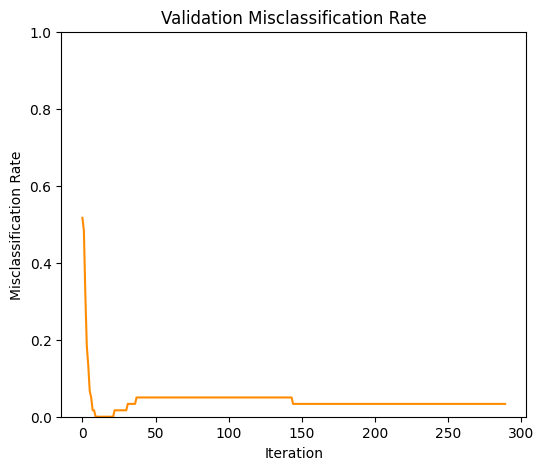

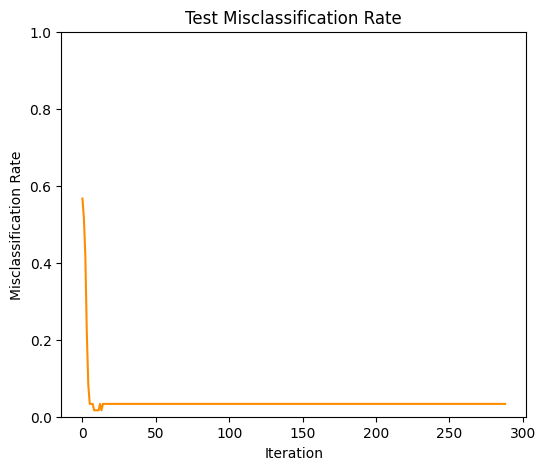

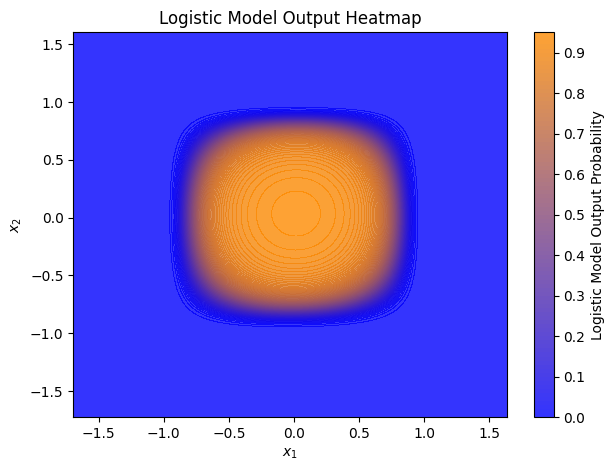

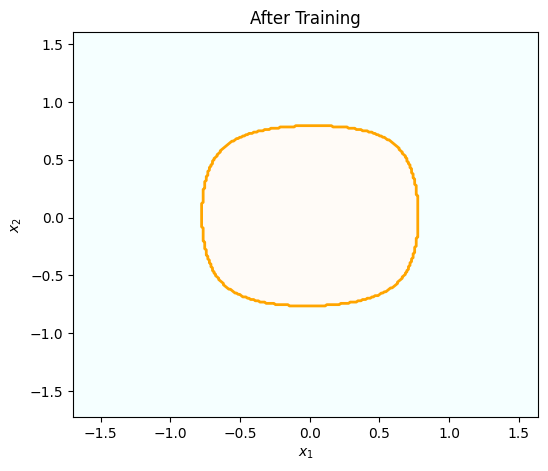

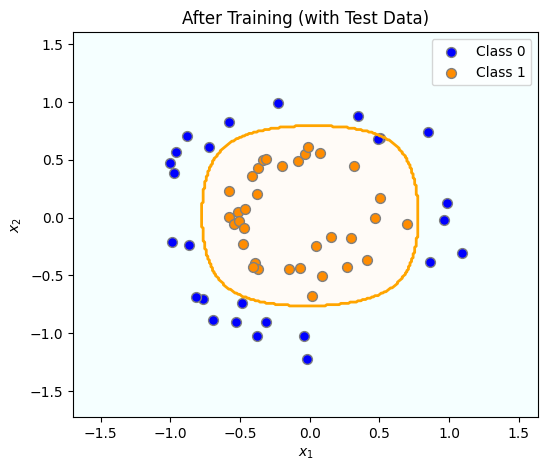

In [2]:
# --- Plot losses and misclassification rates ---
def plot_metric(values, title, ylabel, color):
    plt.figure(figsize=(6, 5))
    plt.plot(values, color=color)
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.ylim(min(0, min(values)), max(1, max(values)))
    plt.title(title)
    plt.show()

# --- Create grid for plotting (based on original 2D space) ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
# Transform grid using the same poly features and add bias term
grid_poly = poly.transform(grid)
grid_poly = np.c_[np.ones(grid_poly.shape[0]), grid_poly]

# --- Refactored plot_decision_regions ---
def plot_decision_regions(model, title, show_points=False, X_points=None, y_points=None, theta_override=None):
    """
    theta_override: 任意で一時的にモデルのパラメータを上書きしてプロットする場合に使用
    """
    if theta_override is not None:
        original_theta = model.theta_.copy()
        model.theta_ = theta_override
        proba = model.predict_proba(grid_poly)[:, 1].reshape(xx.shape)
        model.theta_ = original_theta
    else:
        proba = model.predict_proba(grid_poly)[:, 1].reshape(xx.shape)
    
    Z = (proba >= 0.5)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=region_cmap)
    plt.contour(xx, yy, Z, levels=[0.5], colors=palette["Orange"], linewidths=2)

    if show_points and X_points is not None and y_points is not None:
        for cls in [0, 1]:
            plt.scatter(X_points[y_points == cls, 0], X_points[y_points == cls, 1],
                        c=palette["Blue"] if cls == 0 else palette["Dark Orange"],
                        edgecolor=palette["Gray"], s=50, label=f"Class {cls}")
        plt.legend()
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title(title)
    plt.show()

# --- Plot decision training data ---
plt.figure(figsize=(6, 5))
for cls in [0, 1]:
    plt.scatter(X_train[y_train == cls, 0], X_train[y_train == cls, 1],
                c=palette["Blue"] if cls == 0 else palette["Dark Orange"],
                edgecolor=palette["Gray"], s=50, label=f"Class {cls}")
plt.legend()
plt.xlim(-1.6, 1.6)
plt.ylim(-1.6, 1.6)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Training Data")
plt.show()

# --- Plot decision test data ---
plt.figure(figsize=(6, 5))
for cls in [0, 1]:
    plt.scatter(X_test[y_test == cls, 0], X_test[y_test == cls, 1],
                c=palette["Blue"] if cls == 0 else palette["Dark Orange"],
                edgecolor=palette["Gray"], s=50, label=f"Class {cls}")
plt.legend()
plt.xlim(-1.6, 1.6)
plt.ylim(-1.6, 1.6)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Evaluation Data")
plt.show()

# --- Plot decision regions before training ---
plot_decision_regions(model, "Before Training", theta_override=model.theta_init_)
plot_decision_regions(model, "Before Training (with Test Data)", show_points=True, X_points=X_test, y_points=y_test, theta_override=model.theta_init_)

# --- Plot metrics ---
plot_metric(model.train_loss_, "Training Objective Value", "Objective Value", palette["Purple"])
plot_metric(model.val_loss_, "Validation Cross-Entropy Loss", "Cross-Entropy Loss", palette["Purple"])
plot_metric(model.test_loss_, "Test Cross-Entropy Loss", "Cross-Entropy Loss", palette["Purple"])
plot_metric(model.val_misclass_, "Validation Misclassification Rate", "Misclassification Rate", palette["Dark Orange"])
plot_metric(model.test_misclass_, "Test Misclassification Rate", "Misclassification Rate", palette["Dark Orange"])

# --- Output Heatmap (Logistic Model Probabilities) ---
output_probs = model.predict_proba(grid_poly)[:, 1].reshape(xx.shape)
heatmap_cmap = LinearSegmentedColormap.from_list("heatmap_cmap", [palette["Blue"], palette["Dark Orange"]])
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, output_probs, levels=100, cmap=heatmap_cmap, alpha=0.8)
plt.colorbar(label="Logistic Model Output Probability")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Logistic Model Output Heatmap")
plt.show()

# --- Plot decision regions after training ---
plot_decision_regions(model, "After Training")
plot_decision_regions(model, "After Training (with Test Data)", show_points=True, X_points=X_test, y_points=y_test)

## 各自の実験用コード

Early stopping at iter 9


/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_2127/1512721422.py:25: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


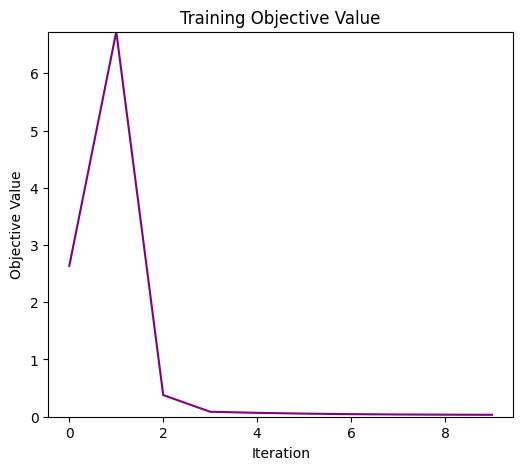

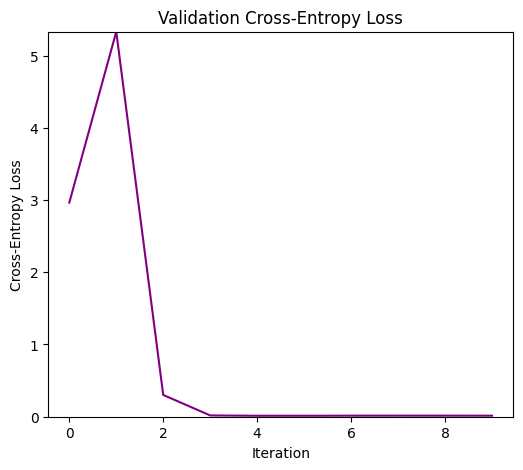

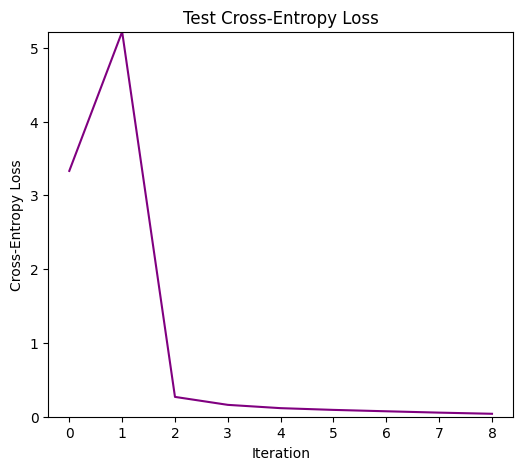

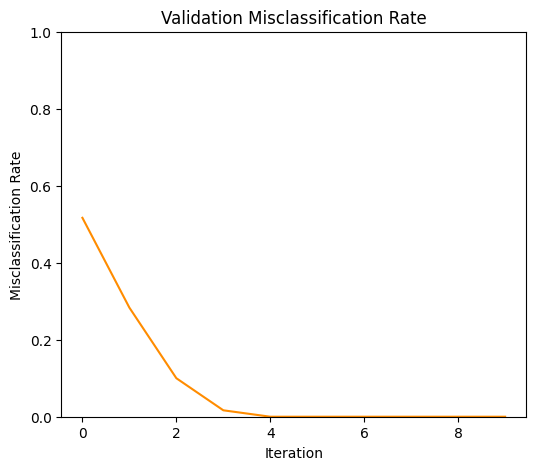

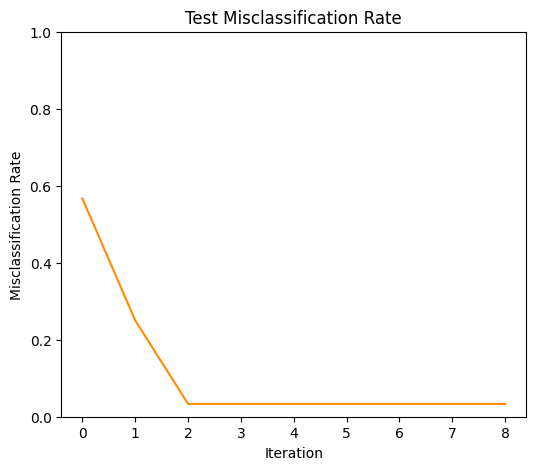

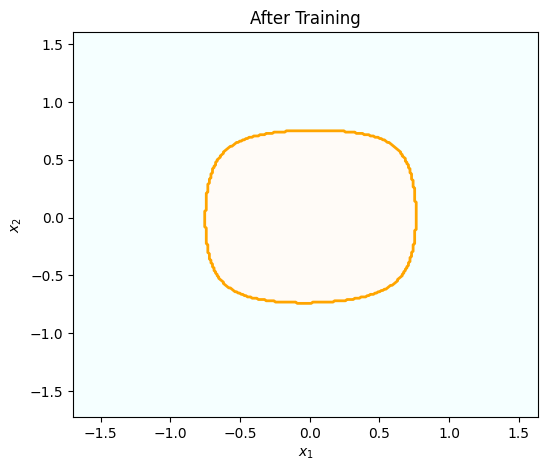

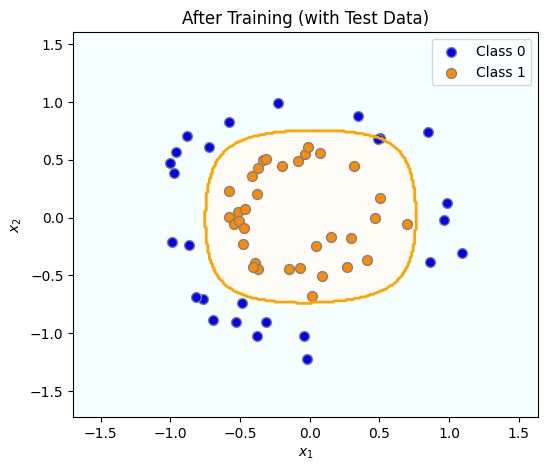

In [3]:
# --- Instantiate and train the model ---
model = LinearInParameterLogisticRegression(learning_rate=100, l2_lambda=0, early_stopping_metric='misclassification_rate', verbose=True)
model.fit(X_train_poly, y_train, X_val=X_val_poly, y_val=y_val, X_test=X_test_poly, y_test=y_test)

# --- Plot metrics ---
plot_metric(model.train_loss_, "Training Objective Value", "Objective Value", palette["Purple"])
plot_metric(model.val_loss_, "Validation Cross-Entropy Loss", "Cross-Entropy Loss", palette["Purple"])
plot_metric(model.test_loss_, "Test Cross-Entropy Loss", "Cross-Entropy Loss", palette["Purple"])
plot_metric(model.val_misclass_, "Validation Misclassification Rate", "Misclassification Rate", palette["Dark Orange"])
plot_metric(model.test_misclass_, "Test Misclassification Rate", "Misclassification Rate", palette["Dark Orange"])

# --- Plot decision regions after training ---
plot_decision_regions(model, "After Training")
plot_decision_regions(model, "After Training (with Test Data)", show_points=True, X_points=X_test, y_points=y_test)